In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

my_ID = 2290
np.random.seed(my_ID)
np.set_printoptions(precision=5,suppress=True)# reduced display precision on numpy arrays

In [2]:
data_train = pd.read_csv('fashion-mnist_train.csv')
data_test = pd.read_csv('fashion-mnist_test.csv')

In [3]:
# create training and validation set
X_train = data_train.iloc[:, 1:].to_numpy()
t_train = data_train.iloc[:,0].to_numpy()
X_train, X_valid, t_train, t_valid = train_test_split(X_train, t_train, test_size=0.2, random_state=my_ID)
X_train = X_train / 255
X_valid = X_valid / 255
print(f"x_train Shape: {X_train.shape}, x_train Type:{type(X_train)})")
print(f"x_valid Shape: {t_valid.shape}, x_valid Type:{type(t_valid)})")

# create test set
X_test = data_test.iloc[:, 1:].to_numpy()
t_test = data_test.iloc[:,0].to_numpy()
X_test = X_test / 255
print(f"x_test Shape: {X_test.shape}, x_test Type:{type(X_test)})")

x_train Shape: (48000, 784), x_train Type:<class 'numpy.ndarray'>)
x_valid Shape: (12000,), x_valid Type:<class 'numpy.ndarray'>)
x_test Shape: (10000, 784), x_test Type:<class 'numpy.ndarray'>)


Small sample data from data_banknote_authentication.txt


In [ ]:
sc = StandardScaler()

dataset = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None)
X_data = dataset.iloc[:, :-1].values
train = dataset.iloc[:, -1].values

rand_seed = 20

# split into train, test and validation set and standardize
X_train, X_test, t_train, t_test = train_test_split(X_data, train, test_size=0.2, random_state=rand_seed)
X_train, X_valid, t_train, t_valid = train_test_split(X_train, t_train, test_size=0.25, random_state=rand_seed)
X_train = sc.fit_transform(X_train)
X_valid = sc.transform(X_valid)
X_test = sc.transform(X_test)

In [8]:
# some convenient code
def l_ce(t, y_pred):
    y_pred[y_pred == 1] = 0.99999999999999999
    y_pred[y_pred == 0] = 0.00000000000000001
    return np.dot(-1 * t, np.log(y_pred)) - np.dot((1 - t), np.log(1 - y_pred))

def l_ce_softmax(t, y_pred):
    t = np.array(t, dtype=int)   # make sure it's integer
    return -np.mean(np.log(y_pred[np.arange(len(t)), t] + 1e-12))

def l_ce_softmax_batch(t, y_pred):
    t = np.asarray(t, dtype=int)
    return -np.mean(np.log(y_pred[np.arange(len(t)), t] + 1e-12))

def sigmoid(z):
    return (1/ (1 + np.exp(-z)))

def relu(h):
    h[h < 0] = 0
    return h


def d_relu(g):
    # relu derivative
    g[g >= 0] = 1
    g[g < 0] = 0
    return g

# def d_relu(g):
#     return (g > 0).astype(float)

def new_w(w, w_J):
    alpha = 0.01
    w_new = w - np.dot(alpha, w_J)
    return w_new

def new_w_adam(w, w_J, t, m, v , alpha=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    # alpha = 0.01
    # w_new = w - np.dot(alpha, w_J)
    
    m = beta1 * m + (1 - beta1) * w_J
    v = beta2 * v + (1 - beta2) * (w_J * w_J)   # element-wise square
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    # Update weights
    w_new = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

    return w_new, m, v


def neural_net_SGD(x, t, Ws):
    L = len(Ws)

    zs = []
    hs = []

    # fwd
    z1 = np.dot(Ws[0], np.r_[1, x.T][:, None])
    # print("z1: {0}\n".format(z1))
    h1 = relu(z1.copy())
    # print("h1: {0}\n".format(h1))
    zs.append(z1)
    hs.append(h1)
    # z2 = np.dot(W2, np.c_[1, h1.T].T)
    # # print("z2: {0}\n".format(z2))
    # h2 = relu(z2.copy())
    # # print("h2: {0}\n".format(h2))

    # middle layers
    h_prev = h1
    for l in range(1,L-1):
        z = np.dot(Ws[l], np.c_[1, h_prev.T].T)
        h = relu(z.copy())
        zs.append(z)
        hs.append(h)
        h_prev = h

    zd = np.dot(Ws[-1], np.c_[1, h_prev.T].T)
    zs.append(zd)
    
    # print('zs = ',zs)
    # print("z3: {0}\n".format(z3))
    # y = 1 / (1 + np.exp(-zd)) # for binary
    exp_z = np.exp(zd - np.max(zd))   # numerical stability
    y = exp_z / np.sum(exp_z)
    hs.append(y) # y is h_d
    #print('hs = ',hs)
    # print("y: {0}\n".format(y))

    # bwd
    # z is 1 shorter than w cus (d-1) d = 3
    w_Js = []
    z_Js = []
    t_one_hot = np.zeros_like(y)
    t_one_hot[int(t)] = 1
    dj_dz_d = -t_one_hot + y  # gradient of cross-entropy loss dJ/dz
    #z_Js.append(dj_dz_d)
    wd_J = dj_dz_d @ np.c_[1, h_prev.T]
    w_Js.append(wd_J)
    zdm1_J = np.multiply(d_relu(zs[-2]), Ws[-1][:, 1:].T @ dj_dz_d)  # element wise multiplication
    z_Js.insert(0,zdm1_J)

    # middle layers (if more than one)
    for l in reversed(range(1, L-1)):
        # dz of current layer
        dz_current = np.multiply(d_relu(zs[l-1]), np.dot(Ws[l][:, 1:].T, z_Js[0]))
        #print("dz_current = ", dz_current)
        z_Js.insert(0, dz_current)  # prepend so z_Js order matches layers
        
        # gradient for weights at this layer
        h_input = hs[l-1] if l > 1 else h1
        #print("h_input = ",h_input)
        w_grad = np.dot(z_Js[1], np.c_[1, h_input.T])
        #print("w_grad = ", w_grad)
        w_Js.insert(0, w_grad)  # prepend so w_Js order matches Ws

    
    w1_J = np.dot(z_Js[0], np.r_[1, x.T][None, :])
    w_Js.insert(0, w1_J)
    
    # print('w_Js = ', w_Js)
    # print('z_Js = ',z_Js)
    # new weights
    # W1_new = new_w(Ws[0], w_Js[0])
    # W2_new = new_w(Ws[1], w_Js[1])
    # W3_new = new_w(Ws[2], w_Js[2])

    lam = 0.001232  # weight decay strength
    #print("z_Js = ", z_Js)
    #print("w_Js = ", w_Js)
    for i in range(len(Ws)):
        w_Js[i][:,1:] += lam * Ws[i][:,1:]

    w_new = []
    for i in range(len(Ws)):
        w_new.append(new_w(Ws[i], w_Js[i]))

    return y, w_new

def neural_net_batch(x, t, Ws, sample_per_batch):
    L = len(Ws)

    zs = []
    hs = []

    # fwd
    Xb = np.c_[np.ones((sample_per_batch, 1)), x]  # shape: (batch_size, n_features+1)
    z1 = Xb @ Ws[0].T  # Ws[0]: (n_hidden, n_features+1), result: (batch_size, n_hidden)
    # print("z1: {0}\n".format(z1))
    h1 = relu(z1.copy())
    # print("h1: {0}\n".format(h1))
    zs.append(z1)
    hs.append(h1)
    # z2 = np.dot(W2, np.c_[1, h1.T].T)
    # # print("z2: {0}\n".format(z2))
    # h2 = relu(z2.copy())
    # # print("h2: {0}\n".format(h2))

    # middle layers
    h_prev = h1
    for l in range(1,L-1):
        H_prev_b = np.c_[np.ones((sample_per_batch, 1)), h_prev]  # add bias
        z = H_prev_b @ Ws[l].T  # shape: (batch_size, n_hidden_next)
        h = relu(z.copy())
        zs.append(z)
        hs.append(h)
        h_prev = h

    H_prev_b = np.c_[np.ones((sample_per_batch,1)), h_prev]
    zd = H_prev_b @ Ws[-1].T
    zs.append(zd)
    
    # print('zs = ',zs)
    # print("z3: {0}\n".format(z3))
    # y = 1 / (1 + np.exp(-zd)) # for binary
    exp_z = np.exp(zd - np.max(zd, axis=1, keepdims=True))  # subtract max per sample
    y = exp_z / np.sum(exp_z, axis=1, keepdims=True)         # softmax per sample
    hs.append(y) # y is h_d
    #print('hs = ',hs)
    # print("y: {0}\n".format(y))

    # bwd
    # z is 1 shorter than w cus (d-1) d = 3
    w_Js = []
    z_Js = []
    t = t.astype(int)
    t_one_hot = np.zeros_like(y)
    t_one_hot[np.arange(sample_per_batch), t] = 1
    dj_dz_d = (y - t_one_hot) / sample_per_batch
    
    #z_Js.append(dj_dz_d)
    H_prev_b = np.c_[np.ones((sample_per_batch, 1)), h_prev]  # batch_size x n_prev+1
    wd_J = dj_dz_d.T @ H_prev_b  # shape: n_classes x (n_prev + 1)
    w_Js.append(wd_J)

    #zdm1_J = np.multiply(d_relu(zs[-2]), Ws[-1][:, 1:].T @ dj_dz_d)  # element wise multiplication
    zdm1_J = (dj_dz_d @ Ws[-1][:,1:]) * d_relu(zs[-2]) # backup
    z_Js.insert(0,zdm1_J)

    # middle layers (if more than one)
    for l in reversed(range(1, L-1)):
        # dz of current layer
        #dz_current = np.multiply(d_relu(zs[l-1]), np.dot(Ws[l][:, 1:].T, z_Js[0]))
        dz_current = (z_Js[0] @ Ws[l][:,1:]) * d_relu(zs[l-1])
        #print("dz_current = ", dz_current)
        z_Js.insert(0, dz_current)  # prepend so z_Js order matches layers
        
        # gradient for weights at this layer
        h_input = hs[l-1] if l > 1 else h1
        #print("h_input = ",h_input)
        H_input_b = np.c_[np.ones((sample_per_batch, 1)), h_input]
        w_grad = dz_current.T @ H_input_b
        #print("w_grad = ", w_grad)
        w_Js.insert(0, w_grad)  # prepend so w_Js order matches Ws

    
    Xb = np.c_[np.ones((sample_per_batch,1)), x]
    w1_J = z_Js[0].T @ Xb
    w_Js.insert(0, w1_J)
    
    # print('w_Js = ', w_Js)
    # print('z_Js = ',z_Js)
    
    lam = 0.001232  # weight decay strength
    #print("z_Js = ", z_Js)
    #print("w_Js = ", w_Js)
    for i in range(len(Ws)):
        w_Js[i][:,1:] += lam * Ws[i][:,1:]

    w_new = []

    for i in range(len(Ws)):
        w_new.append(new_w(Ws[i], w_Js[i]))

    return y, w_new

def neural_net_batch_adam(x, t, Ws, sample_per_batch, t_adam, m_adam, v_adam):
    L = len(Ws)

    zs = []
    hs = []

    # fwd
    Xb = np.c_[np.ones((sample_per_batch, 1)), x]  # shape: (batch_size, n_features+1)
    z1 = Xb @ Ws[0].T  # Ws[0]: (n_hidden, n_features+1), result: (batch_size, n_hidden)
    # print("z1: {0}\n".format(z1))
    h1 = relu(z1.copy())
    # print("h1: {0}\n".format(h1))
    zs.append(z1)
    hs.append(h1)
    # z2 = np.dot(W2, np.c_[1, h1.T].T)
    # # print("z2: {0}\n".format(z2))
    # h2 = relu(z2.copy())
    # # print("h2: {0}\n".format(h2))

    # middle layers
    h_prev = h1
    for l in range(1,L-1):
        H_prev_b = np.c_[np.ones((sample_per_batch, 1)), h_prev]  # add bias
        z = H_prev_b @ Ws[l].T  # shape: (batch_size, n_hidden_next)
        h = relu(z.copy())
        zs.append(z)
        hs.append(h)
        h_prev = h

    H_prev_b = np.c_[np.ones((sample_per_batch,1)), h_prev]
    zd = H_prev_b @ Ws[-1].T
    zs.append(zd)
    
    # print('zs = ',zs)
    # print("z3: {0}\n".format(z3))
    # y = 1 / (1 + np.exp(-zd)) # for binary
    exp_z = np.exp(zd - np.max(zd, axis=1, keepdims=True))  # subtract max per sample
    y = exp_z / np.sum(exp_z, axis=1, keepdims=True)         # softmax per sample
    hs.append(y) # y is h_d
    #print('hs = ',hs)
    # print("y: {0}\n".format(y))

    # bwd
    # z is 1 shorter than w cus (d-1) d = 3
    w_Js = []
    z_Js = []
    t = t.astype(int)
    t_one_hot = np.zeros_like(y)
    t_one_hot[np.arange(sample_per_batch), t] = 1
    dj_dz_d = (y - t_one_hot) / sample_per_batch
    
    #z_Js.append(dj_dz_d)
    H_prev_b = np.c_[np.ones((sample_per_batch, 1)), h_prev]  # batch_size x n_prev+1
    wd_J = dj_dz_d.T @ H_prev_b  # shape: n_classes x (n_prev + 1)
    w_Js.append(wd_J)

    #zdm1_J = np.multiply(d_relu(zs[-2]), Ws[-1][:, 1:].T @ dj_dz_d)  # element wise multiplication
    zdm1_J = (dj_dz_d @ Ws[-1][:,1:]) * d_relu(zs[-2]) # backup
    z_Js.insert(0,zdm1_J)

    # middle layers (if more than one)
    for l in reversed(range(1, L-1)):
        # dz of current layer
        #dz_current = np.multiply(d_relu(zs[l-1]), np.dot(Ws[l][:, 1:].T, z_Js[0]))
        dz_current = (z_Js[0] @ Ws[l][:,1:]) * d_relu(zs[l-1])
        #print("dz_current = ", dz_current)
        z_Js.insert(0, dz_current)  # prepend so z_Js order matches layers
        
        # gradient for weights at this layer
        h_input = hs[l-1] if l > 1 else h1
        #print("h_input = ",h_input)
        H_input_b = np.c_[np.ones((sample_per_batch, 1)), h_input]
        w_grad = dz_current.T @ H_input_b
        #print("w_grad = ", w_grad)
        w_Js.insert(0, w_grad)  # prepend so w_Js order matches Ws

    
    Xb = np.c_[np.ones((sample_per_batch,1)), x]
    w1_J = z_Js[0].T @ Xb
    w_Js.insert(0, w1_J)
    
    # print('w_Js = ', w_Js)
    # print('z_Js = ',z_Js)
    
    lam = 0.001232  # weight decay strength
    #print("z_Js = ", z_Js)
    #print("w_Js = ", w_Js)
    for i in range(len(Ws)):
        w_Js[i][:,1:] += lam * Ws[i][:,1:]

    w_new = []
    t_adam +=1
    for i in range(len(Ws)):
        w_adam,m_adam[i], v_adam[i] = new_w_adam(Ws[i], w_Js[i], t_adam, m_adam[i], v_adam[i])
        w_new.append(w_adam)

    return y, w_new, t_adam, m_adam, v_adam

Epoch 0
training accuracy: 79.79%
Validation accuracy: 80.36%
Epoch 1
training accuracy: 82.32%
Validation accuracy: 83.58%
Epoch 2
training accuracy: 82.75%
Validation accuracy: 78.78%
Epoch 3
training accuracy: 82.72%
Validation accuracy: 83.25%
Epoch 4
training accuracy: 82.81%
Validation accuracy: 82.23%
Epoch 5
training accuracy: 82.92%
Validation accuracy: 83.51%
Epoch 6
training accuracy: 82.99%
Validation accuracy: 84.45%
Epoch 7
training accuracy: 82.85%
Validation accuracy: 83.79%
Epoch 8
training accuracy: 82.81%
Validation accuracy: 82.88%
Epoch 9
training accuracy: 82.82%
Validation accuracy: 83.47%
Epoch 10
training accuracy: 83.04%
Validation accuracy: 81.12%
Epoch 11
training accuracy: 82.96%
Validation accuracy: 83.83%
Early stopping at epoch 11


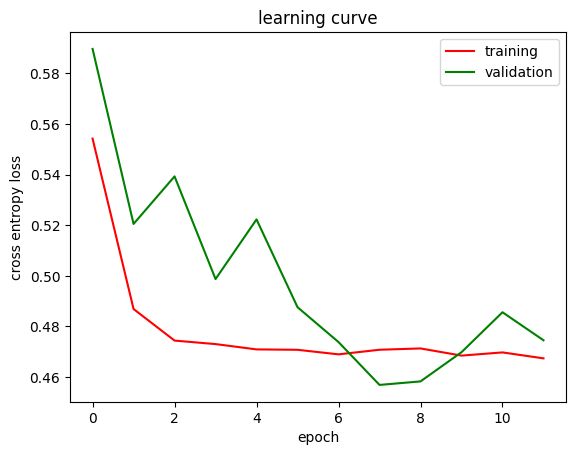



err_train: 0.4673614642051625
err_valid: 0.47451298982389045
Test accuracy: 84.06%
MissClassification rate: 15.94%
err_test: 0.4292873581711354
Epoch 0
training accuracy: 77.67%
Validation accuracy: 79.38%
Epoch 1
training accuracy: 81.63%
Validation accuracy: 83.29%
Epoch 2
training accuracy: 81.97%
Validation accuracy: 81.78%
Epoch 3
training accuracy: 82.17%
Validation accuracy: 82.77%
Epoch 4
training accuracy: 82.21%
Validation accuracy: 80.90%
Epoch 5
training accuracy: 82.23%
Validation accuracy: 83.80%
Epoch 6
training accuracy: 81.92%
Validation accuracy: 80.26%
Epoch 7
training accuracy: 81.78%
Validation accuracy: 82.53%
Epoch 8
training accuracy: 82.02%
Validation accuracy: 82.34%
Epoch 9
training accuracy: 82.18%
Validation accuracy: 81.72%
Epoch 10
training accuracy: 82.19%
Validation accuracy: 80.47%
Early stopping at epoch 10


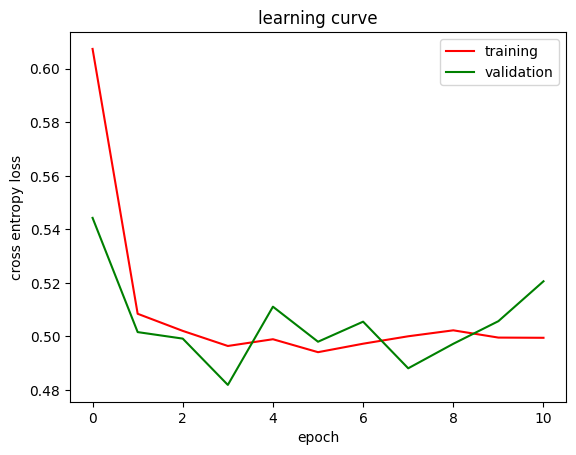



err_train: 0.499516591846045
err_valid: 0.5206233679766002
Test accuracy: 83.69%
MissClassification rate: 16.31%
err_test: 0.46266745042587754
Epoch 0
training accuracy: 71.61%
Validation accuracy: 80.68%
Epoch 1
training accuracy: 79.69%
Validation accuracy: 80.43%
Epoch 2
training accuracy: 80.29%
Validation accuracy: 78.84%
Epoch 3
training accuracy: 79.71%
Validation accuracy: 81.31%
Epoch 4
training accuracy: 79.39%
Validation accuracy: 79.72%
Epoch 5
training accuracy: 79.39%
Validation accuracy: 78.90%
Early stopping at epoch 5


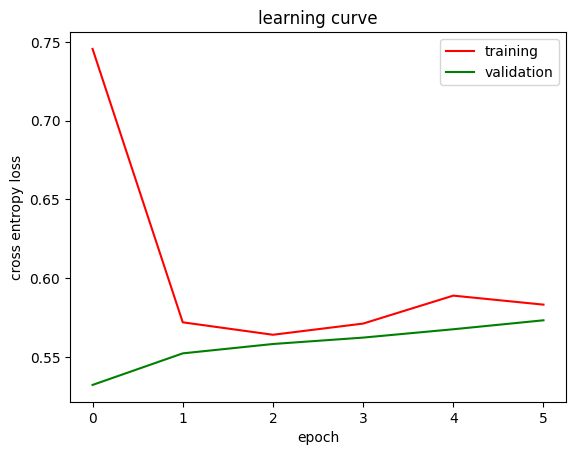



err_train: 0.5832731941611218
err_valid: 0.5733457150580178
Test accuracy: 80.78%
MissClassification rate: 19.22%
err_test: 0.5366844491843418
Epoch 0
training accuracy: 67.15%
Validation accuracy: 71.03%
Epoch 1
training accuracy: 76.99%
Validation accuracy: 73.85%
Epoch 2
training accuracy: 77.94%
Validation accuracy: 75.23%
Epoch 3
training accuracy: 65.13%
Validation accuracy: 70.89%
Epoch 4
training accuracy: 68.62%
Validation accuracy: 62.62%
Epoch 5
training accuracy: 74.12%
Validation accuracy: 77.57%
Epoch 6
training accuracy: 73.44%
Validation accuracy: 72.42%
Epoch 7
training accuracy: 73.97%
Validation accuracy: 76.41%
Epoch 8
training accuracy: 66.02%
Validation accuracy: 59.12%
Epoch 9
training accuracy: 56.65%
Validation accuracy: 66.94%
Epoch 10
training accuracy: 70.38%
Validation accuracy: 74.78%
Early stopping at epoch 10


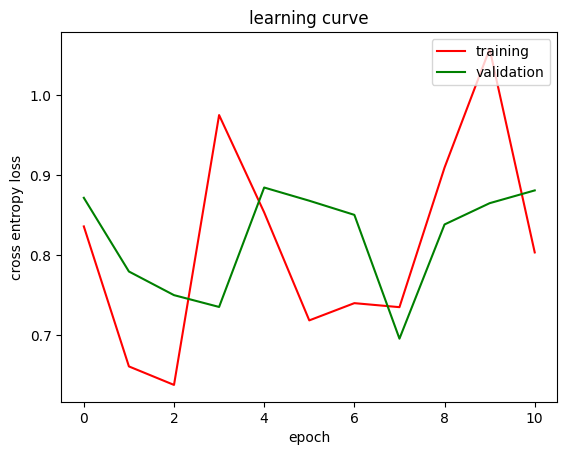



err_train: 0.8031402209659027
err_valid: 0.8807485291768783
Test accuracy: 77.54%
MissClassification rate: 22.46%
err_test: 0.65378608382783


In [11]:
def moving_average_same_length(data, window_size=3):
    ma = []
    for i in range(len(data)):
        start = max(0, i - window_size + 1)
        ma.append(np.mean(data[start:i+1]))
    return ma

def initialize_weights_random(num_hidden_layers, input_size=784, hidden_size_H=80, output_size=10):
    Ws = []

    # Input → first hidden
    W_prev = np.random.randn(hidden_size_H, input_size + 1) * 0.01
    Ws.append(W_prev)

    # Hidden → hidden
    for _ in range(1, num_hidden_layers):
        W_hidden = np.random.randn(hidden_size_H, hidden_size_H + 1) * 0.01
        Ws.append(W_hidden)

    # Hidden → output
    W_out = np.random.randn(output_size, hidden_size_H + 1) * 0.01
    Ws.append(W_out)

    return Ws

def initialize_weights_random_He(num_hidden_layers, input_size=784, hidden_size_H=80, output_size=10):
    Ws = []

    # Input → first hidden
    W_prev = np.random.randn(hidden_size_H, input_size + 1) * np.sqrt(2 / (input_size + 1))
    Ws.append(W_prev)

    # Hidden → hidden
    for _ in range(1, num_hidden_layers):
        W_hidden = np.random.randn(hidden_size_H, hidden_size_H + 1) * np.sqrt(2 / (input_size + 1))
        Ws.append(W_hidden)

    # Hidden → output
    W_out = np.random.randn(output_size, hidden_size_H + 1) * 0.01
    Ws.append(W_out)

    return Ws

def Gradient_desent_SGD(Ws):
    # Setup list to help graph later
    epoch = []
    err_valid = []
    err_train = []
    err_test = []

    # setup for early stop
    best_val = float('inf')
    patience = 5
    wait = 0
    min_delta = 1e-4

    for i in range(100): # epoch
        epoch.append(i)
        print(f'Epoch {i}')

        # SGD shaffle rows each time
        temp_arr = np.c_[X_train, t_train] # This concatenate array along the column axis
        np.random.shuffle(temp_arr)
        X = temp_arr[:, :-1]
        t = temp_arr[:, -1]

        y_train = [] # output
        for j in range(len(X_train)): # iterate through every sample
            # update the weights each iteration
            
            y, Ws = neural_net_SGD(X[j, :], t[j], Ws)
            #print('y=' ,y)
            y_train.append(y.flatten())
            #print ('y_train =', y_train)
        #print(Ws)
        y_train = np.array(y_train) # py list to np array
        # print('shape of y_train np = ', y_train.shape)
        # print("First 5 samples of y_train:\n", y_train[:10])
        # training cross entropy
        ce_loss_train = l_ce_softmax(t, y_train)
        #print('ce_loss=',ce_loss_train)
        err_train.append(ce_loss_train)
        
        # validation cross entropy
        y_valid = []
        for j in range(len(X_valid)):  # iterate through every sample
            # use trained weights each iteration
            
            y, _WS = neural_net_SGD(X_valid[j, :], t_valid[j], Ws)
            y_valid.append(y.flatten())

        y_valid = np.array(y_valid)
        # print("First 5 samples of y_valid:\n", y_train[:10])
        ce_loss_valid = l_ce_softmax(t_valid, y_valid)
        err_valid.append(ce_loss_valid)

        # for signoid obly
        # # if output prob distribution > 0.5, classify it as class 1 else 0
        # y_class = np.where(y_valid > 0.5, 1, 0)
        # misclass_rate = 1 - accuracy_score(t_valid, y_class)

        # softmax
        # training accuracy
        pred_classes = np.argmax(y_train, axis=1)
        accuracy_train = np.mean(pred_classes == t)
        print(f"training accuracy: {accuracy_train * 100:.2f}%")
        # valid accuracy
        pred_classes = np.argmax(y_valid, axis=1)
        accuracy_valid = np.mean(pred_classes == t_valid)

        print(f"Validation accuracy: {accuracy_valid * 100:.2f}%")
        # for i in range(len(t_valid)):
        #     print(f"Sample {i}: Predicted = {pred_classes[i]}, Actual = {int(t_valid[i])}")

        # early stop
        # early stop
        if ce_loss_valid < best_val - min_delta:
            best_val = ce_loss_valid
            best_weights = [W.copy() for W in Ws]
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {i}")
            Ws = best_weights
            break
        
    valid_error_moving_average = moving_average_same_length(err_valid, window_size=3)
    # plot learning curve
    plt.plot(epoch, err_train, color='red', label='training')
    plt.plot(epoch, valid_error_moving_average, color='green', label='validation')
    plt.title('learning curve')
    plt.legend(loc='upper right')
    plt.xlabel('epoch')
    plt.ylabel('cross entropy loss')
    plt.show()
    print("\n")

    # calc validation, training error
    print("err_train: {0}".format(err_train[-1]))
    print("err_valid: {0}".format(valid_error_moving_average[-1]))

    # testing cross entropy
    y_test = []
    for j in range(len(X_test)):  # iterate through every sample
        # use trained weights each iteration
        
        y, _WS = neural_net_SGD(X_test[j, :], t_test[j], Ws)
        y_test.append(y.flatten())

    y_test = np.array(y_test)
    # print("First 5 samples of y_valid:\n", y_train[:10])
    ce_loss_test = l_ce_softmax(t_test, y_test)
    err_test.append(ce_loss_test)
    pred_classes = np.argmax(y_test, axis=1)
    accuracy_test = np.mean(pred_classes == t_test)
    test_error_moving_average = moving_average_same_length(err_test, window_size=3)
    print(f"Test accuracy: {accuracy_test * 100:.2f}%")
    print(f"MissClassification rate: {(1- accuracy_test) * 100:.2f}%")
    print("err_test: {0}".format(test_error_moving_average[-1]))


def Gradient_desent_Batch(Ws):
    # Setup list to help graph later
    epoch = []
    err_valid = []
    err_train = []
    batch_size = 100
    err_test = []

    # setup for early stop
    best_val = float('inf')
    patience = 5
    wait = 0
    min_delta = 1e-4

    for i in range(100): # epoch
        epoch.append(i)
        print(f'Epoch {i}')

        # SGD shaffle rows each time
        temp_arr = np.c_[X_train, t_train] # This concatenate array along the column axis
        np.random.shuffle(temp_arr)
        X = temp_arr[:, :-1]
        t = temp_arr[:, -1]

        

        y_train = [] # output
        for j in range(0, len(X), batch_size): # iterate through every sample
            # extract the batch 
            X_batch = X[j:j+batch_size]
            t_batch = t[j:j+batch_size]
            
            # update the weights each iteration
            
            y, Ws = neural_net_batch(X_batch, t_batch, Ws, len(X_batch))
            #print('y=' ,y)
            y_train.append(y)
            #print ('y_train =', y_train)
        y_train = np.vstack(y_train)
        #print(Ws)
        y_train = np.array(y_train) # py list to np array
        # print('shape of y_train np = ', y_train.shape)
        # print("First 5 samples of y_train:\n", y_train[:10])
        # training cross entropy
        ce_loss_train = l_ce_softmax_batch(t, y_train)
        #print('ce_loss=',ce_loss_train)
        err_train.append(ce_loss_train)
        

        # validation cross entropy
        # no change bacuse doesnt matter
        y_valid = []
        for j in range(len(X_valid)):  # iterate through every sample
            # use trained weights each iteration
            
            y, _WS = neural_net_SGD(X_valid[j, :], t_valid[j], Ws)
            y_valid.append(y.flatten())

        y_valid = np.array(y_valid)
        # print("First 5 samples of y_valid:\n", y_train[:10])
        ce_loss_valid = l_ce_softmax_batch(t_valid, y_valid)
        err_valid.append(ce_loss_valid)

        pred_classes = np.argmax(y_train, axis=1)
        accuracy_train = np.mean(pred_classes == t)
        print(f"training accuracy: {accuracy_train * 100:.2f}%")

        pred_classes = np.argmax(y_valid, axis=1)
        accuracy_valid = np.mean(pred_classes == t_valid)

        print(f"Validation accuracy: {accuracy_valid * 100:.2f}%")

        # early stop
        # early stop
        if ce_loss_valid < best_val - min_delta:
            best_val = ce_loss_valid
            best_weights = [W.copy() for W in Ws]
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {i}")
            Ws = best_weights
            break
        
    valid_error_moving_average = moving_average_same_length(err_valid, window_size=3)
    # plot learning curve
    plt.plot(epoch, err_train, color='red', label='training')
    plt.plot(epoch, valid_error_moving_average, color='green', label='validation')
    plt.title('learning curve')
    plt.legend(loc='upper right')
    plt.xlabel('epoch')
    plt.ylabel('cross entropy loss')
    plt.show()
    print("\n")

    # calc validation, training error
    print("err_train: {0}".format(err_train[-1]))
    print("err_valid: {0}".format(valid_error_moving_average[-1]))

    # testing cross entropy
    y_test = []
    for j in range(len(X_test)):  # iterate through every sample
        # use trained weights each iteration
        
        y, _WS = neural_net_SGD(X_test[j, :], t_test[j], Ws)
        y_test.append(y.flatten())

    y_test = np.array(y_test)
    # print("First 5 samples of y_valid:\n", y_train[:10])
    ce_loss_test = l_ce_softmax(t_test, y_test)
    err_test.append(ce_loss_test)
    pred_classes = np.argmax(y_test, axis=1)
    accuracy_test = np.mean(pred_classes == t_test)
    test_error_moving_average = moving_average_same_length(err_test, window_size=3)
    print(f"Test accuracy: {accuracy_test * 100:.2f}%")
    print(f"MissClassification rate: {(1- accuracy_test) * 100:.2f}%")
    print("err_test: {0}".format(test_error_moving_average[-1]))

def Gradient_desent_Batch_Adam(Ws):
    # Setup list to help graph later
    epoch = []
    err_valid = []
    err_train = []
    batch_size = 1
    err_test = []

    # setup for early stop
    best_val = float('inf')
    patience = 5
    wait = 0
    min_delta = 1e-4

    # count interation for graphing
    iteration = 0
    # initialize adam
    t_adam = 0
    m_adam = [np.zeros_like(W) for W in Ws]
    v_adam = [np.zeros_like(W) for W in Ws]

    for i in range(100): # epoch
        epoch.append(i)
        print(f'Epoch {i}')

        # SGD shaffle rows each time
        temp_arr = np.c_[X_train, t_train] # This concatenate array along the column axis
        np.random.shuffle(temp_arr)
        X = temp_arr[:, :-1]
        t = temp_arr[:, -1]

        

        y_train = [] # output
        for j in range(0, len(X), batch_size): # iterate through every sample
            # extract the batch 
            X_batch = X[j:j+batch_size]
            t_batch = t[j:j+batch_size]
            
            # update the weights each iteration
            
            y, Ws, t_adam, m_adam, v_adam = neural_net_batch_adam(X_batch, t_batch, Ws, len(X_batch), t_adam, m_adam, v_adam)
            #print('y=' ,y)
            y_train.append(y)
            #print ('y_train =', y_train)
        y_train = np.vstack(y_train)
        #print(Ws)
        y_train = np.array(y_train) # py list to np array
        # print('shape of y_train np = ', y_train.shape)
        # print("First 5 samples of y_train:\n", y_train[:10])
        # training cross entropy
        ce_loss_train = l_ce_softmax_batch(t, y_train)
        #print('ce_loss=',ce_loss_train)
        err_train.append(ce_loss_train)
        

        # validation cross entropy
        # no change bacuse doesnt matter
        y_valid = []
        for j in range(len(X_valid)):  # iterate through every sample
            # use trained weights each iteration
            
            y, _WS = neural_net_SGD(X_valid[j, :], t_valid[j], Ws)
            y_valid.append(y.flatten())

        y_valid = np.array(y_valid)
        # print("First 5 samples of y_valid:\n", y_train[:10])
        ce_loss_valid = l_ce_softmax_batch(t_valid, y_valid)
        err_valid.append(ce_loss_valid)

        pred_classes = np.argmax(y_train, axis=1)
        accuracy_train = np.mean(pred_classes == t)
        print(f"training accuracy: {accuracy_train * 100:.2f}%")

        pred_classes = np.argmax(y_valid, axis=1)
        accuracy_valid = np.mean(pred_classes == t_valid)

        print(f"Validation accuracy: {accuracy_valid * 100:.2f}%")

        # early stop
        if ce_loss_valid < best_val - min_delta:
            best_val = ce_loss_valid
            best_weights = [W.copy() for W in Ws]
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {i}")
            Ws = best_weights
            break
        
    valid_error_moving_average = moving_average_same_length(err_valid, window_size=3)
    # plot learning curve
    plt.plot(epoch, err_train, color='red', label='training')
    plt.plot(epoch, valid_error_moving_average, color='green', label='validation')
    plt.title('learning curve')
    plt.legend(loc='upper right')
    plt.xlabel('epoch')
    plt.ylabel('cross entropy loss')
    plt.show()
    print("\n")

    # calc validation, training error
    print("err_train: {0}".format(err_train[-1]))
    print("err_valid: {0}".format(valid_error_moving_average[-1]))

    # testing cross entropy
    y_test = []
    for j in range(len(X_test)):  # iterate through every sample
        # use trained weights each iteration
        
        y, _WS = neural_net_SGD(X_test[j, :], t_test[j], Ws)
        y_test.append(y.flatten())

    y_test = np.array(y_test)
    # print("First 5 samples of y_valid:\n", y_train[:10])
    ce_loss_test = l_ce_softmax(t_test, y_test)
    err_test.append(ce_loss_test)
    pred_classes = np.argmax(y_test, axis=1)
    accuracy_test = np.mean(pred_classes == t_test)
    test_error_moving_average = moving_average_same_length(err_test, window_size=3)
    print(f"Test accuracy: {accuracy_test * 100:.2f}%")
    print(f"MissClassification rate: {(1- accuracy_test) * 100:.2f}%")
    print("err_test: {0}".format(test_error_moving_average[-1]))

def main():

    # number_of_hidden_layer = 2
    # #Ws = initialize_weights(number_of_hidden_layer)
    # Ws = initialize_weights_random_He(number_of_hidden_layer)
    Ws = []
    for i in range(1,5):
        Ws_i = initialize_weights_random_He(i)
        Ws.append(Ws_i)

    for w in Ws:
        
        #Gradient_desent_SGD(w)
        Gradient_desent_Batch_Adam(w)



        

if __name__ == '__main__':
    main()

In [55]:
Ws = []
for i in range(1,5):
    Ws_i = initialize_weights_random_He(i)
    Ws.append(Ws_i)

sizes = [(len(mat), len(mat[0]) if mat else 0) for mat in Ws]
print(sizes)

[(2, 80), (3, 80), (4, 80), (5, 80)]
